# Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 
# pour afficher facilement les graphiques 
from urllib.request import urlopen
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET
import os
import re
from pathlib import Path



# Fonction 

note : ajouter les entetes aux fichierx txt 
optimisation : créer une fonction d'écriture dans les fichiers 
ajouter les chemain absolues 



In [3]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().parent

BULLETINS = BASE_DIR / "BULLETINS"
DATA = BASE_DIR / "data"
OUTPUT = BASE_DIR / "output"

In [6]:
def export(file_name, nb_colonnes, liste_finale):
    if nb_colonnes > 1 :
        with open(file_name, "w") as f:
            for element in liste_finale :
                line = ""
                for i in range(nb_colonnes) :
                    line = line + f"{element[i]} \t" 
                line = line + " \n"
                f.writelines(line)
    if nb_colonnes == 1 :
        with open(file_name, "w") as f:
            for element in liste_finale :
                line = f"{element} \t" 
                f.writelines(line)

def segmente(corpus):

    with open(corpus , "r" , encoding="utf8") as c:
        contenu = c.read()

    tokens = []
    soup = BeautifulSoup(contenu , "html.parser")

    documents = soup.find_all("document")

    for doc in documents:

        id_document = doc.find("article").text
        titre = doc.find("titre").text
        texte = doc.find("texte").text

        texte_total = titre + " " + texte

        token = re.findall(r"\b\w+\b", texte_total.lower())

        for mot in token:
            tokens.append([id_document , mot])
            
    #export des fichiers
    export(DATA/"tokens.txt", 2, tokens)


def frequenced_apparition(fichier):

    # construction du dictionnaire de fichier  
    dictionnaire = {}
    with open(fichier, "r") as f:
        for ligne in f:
            ligne_element = ligne.split()

            if not ligne_element:
                continue

            if ligne_element[0] in dictionnaire:
                dictionnaire[ligne_element[0]].append(ligne_element[1])
            else:
                dictionnaire[ligne_element[0]] = []
                dictionnaire[ligne_element[0]].append(ligne_element[1])
    
    # construction le la liste de liste contenant le id_document le token tftd
    liste_tftd  = []
    for dict in dictionnaire :
        for token in dictionnaire[dict] :
            tftd = dictionnaire[dict].count(token)
            liste_tftd.append([dict, token, tftd ])
    
    # suppression des doublons 
    liste_final = []
    for sous_liste in liste_tftd :
        if sous_liste not in liste_final :
            liste_final.append(sous_liste)

    # ecriture dans le fichier
    export(OUTPUT/"frequence_tftd.txt", 3, liste_final)

def coefficients_idft(fichier):
    # construciton d'un ditionnaire dont les elements au niveau 1 sont les mots .
    # au niveau 2 on a une liste de id de documents dans les quelles on trouve ses mots 
    # {'pomme': ['1'], 'chaise': ['2']}
    dictionnaire = {}
    liste_document = []
    with open(fichier, "r") as f:
        for ligne in f:
            ligne_element = ligne.split()

            if not ligne_element:
                continue

            #construction de la liste de documents 
            liste_document.append(ligne_element[0])

            if ligne_element[1] in dictionnaire and ligne_element[0] not in dictionnaire[ligne_element[1]] :
                dictionnaire[ligne_element[1]].append(ligne_element[0])
            else:
                dictionnaire[ligne_element[1]] = []
                dictionnaire[ligne_element[1]].append(ligne_element[0])
   
        print(dictionnaire)
    N  = len(list(set(liste_document)))
    # construction le la liste de liste contenant le token idft
    liste_idft  = []
    for token in dictionnaire :
        dft = len(dictionnaire[token])
        idft = np.log10(N / dft)
        liste_idft.append([ token , round(idft,4) ])

    # suppression des doublons 
    liste_final = []
    for sous_liste in liste_idft :
        if sous_liste not in liste_final :
            liste_final.append(sous_liste)
    
    # ecriture dans le fichier
    export(OUTPUT/"coeffecient_idft.txt", 2, liste_final)


def coefficients_tf_idft(file_idft, file_tftd):
    # ouverture du fichier idft
    with open(file_idft, "r") as f:
        lignes_idft = f.readlines()
        print("line_idft", lignes_idft)
    # ouverture du fichier tftd
    with open(file_tftd, "r") as f:
        lignes_tfdt = f.readlines()

    # construction de la liste contenant les trois colones : token , id-document , idft * tf
    liste_semi_finale = []
    for line_x in lignes_idft :
        for line_y in lignes_tfdt :
            if line_x.split()[0] == line_y.split()[1] :
                produit = float(line_x.split()[1]) * float(line_y.split()[2])
                id_document = line_y.split()[0]
                token = line_x.split()[0]
                liste_semi_finale.append([token, id_document, produit])

    # suppression des doublons
    liste_finale = []
    for sous_liste in liste_semi_finale :
        if sous_liste not in liste_finale:
            liste_finale.append(sous_liste)

    print(liste_finale)
    # ecriture dans le fichier 
    export(OUTPUT/"fichier_tf_idft.txt", 3, liste_finale)




def anti_dictionnaire(fichier, seuil_min , seuil_max):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    
    # anti dictionnaire 
    liste_semi_finale = []
    for line in lines :
        coef = float(line.split()[3])
        token = line.split()[0]
        if  coef < seuil_min and coef > seuil_max :
            liste_semi_finale.append(token)

    # suppression de doublons 
    liste_finale = list(set(liste_semi_finale))

    # Ecriture dans le fichier 
    export(OUTPUT/"frequence_tftd.txt", 1, liste_finale)


fichier = DATA / "tokens.txt"
chemin = OUTPUT/"corpus.xml"
segmente(chemin)
frequenced_apparition(fichier)
coefficients_idft(OUTPUT/"frequence_tftd.txt")
coefficients_tf_idft(OUTPUT/"coeffecient_idft.txt", OUTPUT/"frequence_tftd.txt" )


{'physique': ['67068', '67798', '67943', '68280', '68638', '68883', '69178', '69180', '69540', '70167', '70422', '70424', '70914', '72934', '73186', '73188', '73688', '74168', '74170', '74745', '75070', '75791', '75794'], 'mathias': ['67068'], 'fink': ['67068'], 'un': ['67068', '67071', '67383', '67385', '67386', '67387', '67388', '67389', '67390', '67391', '67553', '67554', '67555', '67556', '67557', '67558', '67561', '67794', '67795', '67796', '67797', '67798', '67799', '67800', '67801', '67802', '67804', '67937', '67938', '67939', '67940', '67941', '67942', '67943', '67944', '68273', '68274', '68275', '68276', '68277', '68278', '68279', '68280', '68281', '68283', '68383', '68384', '68385', '68386', '68387', '68388', '68389', '68390', '68391', '68393', '68638', '68639', '68640', '68641', '68642', '68643', '68644', '68645', '68646', '68881', '68882', '68883', '68884', '68885', '68886', '68887', '68888', '68889', '69177', '69178', '69179', '69181', '69182', '69183', '69184', '69185', '

# ANALYSE

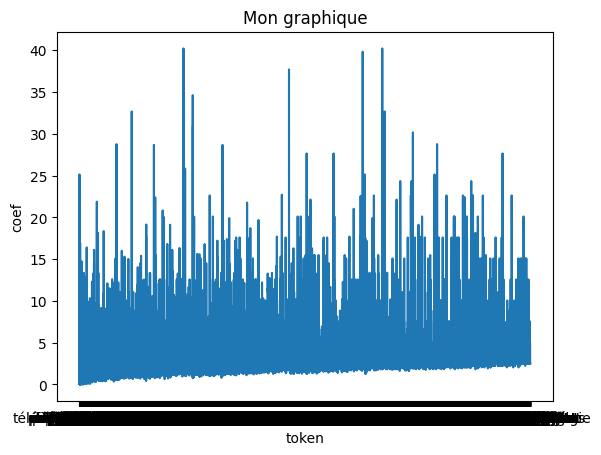

In [7]:
def courbe_analytique(fichier, id_doc):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    
    x = []
    y = []
    if id_doc == 0 :
        for line in lines :
            x.append(line.split()[0])
            y.append(float(line.split()[2]))
    if id_doc != 0 :
        for line in lines :
            if int(line.split()[1]) == id_doc :
                x.append(line.split()[0])
                y.append(float(line.split()[2]))
    
    plt.plot(x, y)

    plt.title("Mon graphique")
    plt.xlabel("token")
    plt.ylabel("coef")

    plt.show()

fichier = OUTPUT/"fichier_tf_idft.txt"
courbe_analytique(fichier, 0)
    

taille : 59
{'mathias': 25.131999999999998, 'fink': 25.131999999999998, 'plantes': 21.8736, 'actilait': 28.7586, 'eden': 32.6716, 'froid': 28.668, 'mousse': 22.3971, 'scénario': 20.8212, 'agroparistech': 20.0172, 'jules': 27.7616, 'hoffmann': 40.2112, 'académie': 24.378, 'tropiques': 34.613699999999994, 'mégha': 30.970800000000004, 'cnes': 20.076, 'janny': 22.6188, 'resqme': 20.1056, 'artemis': 28.668, 'lasers': 21.770400000000002, 'calcul': 22.698, 'sérotonine': 37.698, 'dopage': 20.1056, 'cfp': 20.1056, 'envisat': 27.6452, 'dengue': 20.1056, 'sénégal': 22.122, 'pompier': 27.6452, 'virtuel': 20.360999999999997, 'rame': 20.1056, 'démantèlement': 21.0232, 'cuisine': 22.5563, 'cheval': 39.8196, 'isae': 25.131999999999998, 'medtech': 22.6188, 'théorème': 40.2112, 'pléiades': 32.6716, 'toxines': 22.122, 'bleu': 24.334200000000003, 'nucadvisor': 22.6188, 'ingérop': 24.334200000000003, 'pastel': 30.1584, 'mathématicienne': 20.1056, 'tara': 25.131999999999998, 'vitamine': 20.1056, 'lipoprotéi

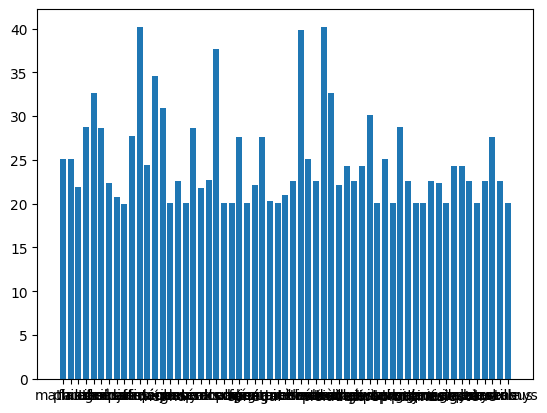

In [5]:

frequence = {
    "pomme":3,
    "livre":1,
    "table":2
}


def courbe_analytique(fichier, id_doc):
    with open(fichier, 'r') as f :
        lines = f.readlines()
    # frequence vas collecter collecter les données
    frequence = {}

    # le id document c'est pour specifier le document dont on cherche les mots
    if id_doc == 0 :
        for line in lines :
            if float(line.split()[2]) > 20 :
                frequence[line.split()[0]] = float(line.split()[2])
    if id_doc != 0 :
        for line in lines :
            if int(line.split()[1]) == id_doc :
                frequence[line.split()[0]] = float(line.split()[2])
        
    plt.bar(frequence.keys(), frequence.values())
    print("taille :", len(frequence))
    print(frequence)
    plt.show()

fichier = OUTPUT/"fichier_tf_idft.txt"
courbe_analytique(fichier, 0)
    

# Test

with open("fichier.txt", "w") as f:
    f.write("Bonjour\n")
    f.write("Monde\n")

nombre total de mots : 14293

nombre total de mots > 10 : 557

nombre total de mots > 20 : 59


